HUYỀN

KẾT NỐI SQL

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import pickle
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')

SERVER_NAME = 'LAPTOP-BPDB2BM4\\SQLEXPRESS' # Hoặc 'DESKTOP-06I4T19\SQLEXPRESS'
DATABASE_NAME = 'CarProject'
DRIVER_NAME = 'ODBC Driver 17 for SQL Server'
connection_url = f"mssql+pyodbc://@{SERVER_NAME}/{DATABASE_NAME}?driver={DRIVER_NAME.replace(' ', '+')}&trusted_connection=yes"
engine = create_engine(connection_url)

print("✅ Đồ nghề và kết nối SQL đã sẵn sàng!")

✅ Đồ nghề và kết nối SQL đã sẵn sàng!


ĐƯA DỮ LIỆU VÀO SQL

In [7]:
# 1. Đọc file CSV gốc
df_raw = pd.read_csv('car_price_prediction.csv')

# 2. Đẩy thẳng toàn bộ vào SQL Server thành một bảng tên là 'Cars_Raw'
df_raw.to_sql('Cars_Raw', con=engine, if_exists='replace', index=False)

print("✅ Đã nhập kho dữ liệu thô vào bảng 'Cars_Raw' trong SQL Server.")

✅ Đã nhập kho dữ liệu thô vào bảng 'Cars_Raw' trong SQL Server.


CHỌN FEATURE

In [8]:

sql_query = """
SELECT 
    Price, Levy, Manufacturer, Model, [Prod. year], Category, 
    [Fuel type], [Engine volume], Mileage, [Leather interior],
    Cylinders, [Gear box type], [Drive wheels], 
    Color, Airbags
FROM Cars_Raw

"""

# Thực thi SQL và kéo dữ liệu sạch (đã lọc đáy) về Pandas
df = pd.read_sql_query(sql_query, con=engine)

print(f"✅ Đã dùng truy vấn SQL rút {df.shape[1]} ")
df.head(3)

✅ Đã dùng truy vấn SQL rút 15 


,Price,Levy,Manufacturer,Model,Prod. year,Category,Fuel type,Engine volume,Mileage,Leather interior,Cylinders,Gear box type,Drive wheels,Color,Airbags
0,13328,1399,LEXUS,RX 450,2010,Jeep,Hybrid,3.5,186005 km,Yes,6.0,Automatic,4x4,Silver,12
1,16621,1018,CHEVROLET,Equinox,2011,Jeep,Petrol,3,192000 km,No,6.0,Tiptronic,4x4,Black,8
2,8467,-,HONDA,FIT,2006,Hatchback,Petrol,1.3,200000 km,No,4.0,Variator,Front,Black,2


XỬ LÍ DỮ LIỆU

In [9]:
# Xử lý cột Mileage (xóa ' km') và điền ô trống bằng Median
df['Mileage'] = df['Mileage'].astype(str).str.replace(' km', '')
df['Mileage'] = pd.to_numeric(df['Mileage'], errors='coerce')
df['Mileage'].fillna(df['Mileage'].median(), inplace=True)

# Hierarchical Imputation cho cột Levy (Thuế/Phí)
df['Levy'] = pd.to_numeric(df['Levy'], errors='coerce')

# Lớp lưới 1: Nội suy chính xác theo Hãng + Năm + Động cơ + Loại Nhiên liệu
df['Levy'] = df['Levy'].fillna(
    df.groupby(['Manufacturer', 'Prod. year', 'Engine volume', 'Fuel type'])['Levy'].transform('median')
)

# Lớp lưới 2: Nới lỏng - Lấy theo Hãng + Năm sản xuất
df['Levy'] = df['Levy'].fillna(
    df.groupby(['Manufacturer', 'Prod. year'])['Levy'].transform('median')
)

# Lớp lưới 3: Nới lỏng - Lấy theo Phân khúc xe (Category)
df['Levy'] = df['Levy'].fillna(
    df.groupby('Category')['Levy'].transform('median')
)

# Lớp lưới 4: Lưới an toàn cuối cùng - Median toàn cục
df['Levy'] = df['Levy'].fillna(df['Levy'].median())

# === TRÍCH XUẤT TURBO & TUỔI XE TRƯỚC KHI LỌC OUTLIER ===
# 1. Tạo cột 'is_Turbo' và làm sạch cột 'Engine volume'
df['is_Turbo'] = df['Engine volume'].astype(str).str.contains('Turbo', case=False).astype(int)
df['Engine volume'] = df['Engine volume'].astype(str).str.replace(' Turbo', '', case=False).str.strip()
df['Engine volume'] = pd.to_numeric(df['Engine volume'], errors='coerce')

# 2. Chuyển năm sản xuất thành tuổi xe
df['Car_Age'] = 2024 - df['Prod. year']
df.drop('Prod. year', axis=1, inplace=True) # Xóa cột cũ

print("✅ Đã xử lý Missing Values, Levy, is_Turbo và Car_Age!")


✅ Đã xử lý Missing Values, Levy, is_Turbo và Car_Age!


HIẾU

XỬ LÍ OUTLIER

In [10]:
initial_rows = df.shape[0]

df_final = df[
    (df['Price']   >= 1_000)   & (df['Price']   <= 100_000) &
    (df['Mileage'] >= 1_000)   & (df['Mileage'] <= 400_000)
]

final_rows = df_final.shape[0]
print(f"✅ Da loc xong ngoai lai!")
print(f"👉 So dong bi loai: {initial_rows - final_rows:,} dong")
print(f"📉 Gia xe: {df_final['Price'].min():,.0f}$ → {df_final['Price'].max():,.0f}$")
print(f"📏 So km: {df_final['Mileage'].min():,.0f} km → {df_final['Mileage'].max():,.0f} km")
print(f"📊 Con lai: {final_rows:,} dong")


✅ Da loc xong ngoai lai!
👉 So dong bi loai: 3,654 dong
📉 Gia xe: 1,000$ → 99,440$
📏 So km: 1,000 km → 400,000 km
📊 Con lai: 15,583 dong


In [11]:
# Lưu phiên bản đã làm sạch đẹp đẽ thành một bảng mới để bạn số 2 lấy ra dùng
df_final.to_sql('Cars_Cleaned', con=engine, if_exists='replace', index=False)

print("🚀 HOÀN TẤT! Dữ liệu sạch đã nằm trong bảng 'Cars2_Cleaned'. Bàn giao cho Người 2!")

🚀 HOÀN TẤT! Dữ liệu sạch đã nằm trong bảng 'Cars2_Cleaned'. Bàn giao cho Người 2!


MÃ HÓA DỮ LIỆU

In [12]:
# 1. Đảm bảo đủ 8 cột cần mã hóa
cat_features = ['Manufacturer', 'Model', 'Category', 'Fuel type', 
                'Gear box type', 'Drive wheels', 'Color', 'Leather interior']

# 2. Xử lý rác phông chữ TRƯỚC KHI mã hóa (Đổi ???? thành Other)
for col in ['Manufacturer', 'Model']:
    df_final[col] = df_final[col].apply(lambda x: 'Other' if '?' in str(x) or 'სხვა' in str(x) else x)

global_mean = df_final['Price'].mean()
encoding_dict = {}
encoding_dict['global_mean'] = global_mean 

# 3. Tạo Bản đồ Hãng xe -> Dòng xe (Lúc này df_final vẫn đang là CHỮ)
mfg_model_mapping = df_final.groupby('Manufacturer')['Model'].unique().apply(list).to_dict()
encoding_dict['mfg_model_mapping'] = mfg_model_mapping

# 4. Vòng lặp thần thánh: Vừa lưu từ điển (CHỮ), vừa mã hóa thành (SỐ)
for col in cat_features:
    # Lấy trung bình giá (Lưu vào từ điển dưới dạng CHỮ)
    mean_map = df_final.groupby(col)['Price'].mean().to_dict()
    encoding_dict[col] = mean_map
    
    # Ép kiểu dữ liệu hiện tại thành SỐ
    df_final[col] = df_final[col].map(mean_map).fillna(global_mean)

# 5. Xuất từ điển ra file
with open('target_encoders.pkl', 'wb') as f:
    pickle.dump(encoding_dict, f)

print("✅ Đã lưu từ điển thành công! Test thử Hãng xe:")
print(list(encoding_dict['Manufacturer'].keys())[:5])

✅ Đã lưu từ điển thành công! Test thử Hãng xe:
['ACURA', 'ALFA ROMEO', 'ASTON MARTIN', 'AUDI', 'BMW']


CHIA TẬP DỮ LIỆU

In [13]:
from sklearn.model_selection import train_test_split

# 1. Chia tập dữ liệu thành 80% Train và 20% Test
# Chúng ta chia trên chính df_final đã được Label Encoding và xử lý xong
train_df, test_df = train_test_split(df_final, test_size=0.2, random_state=42)

# 2. Xuất ra file CSV (loại bỏ cột index để file gọn hơn)
train_df.to_csv('car_price_train_clean.csv', index=False)
test_df.to_csv('car_price_test_clean.csv', index=False)

print("✅ Đã chia và xuất file thành công!")
print(f"📊 Tập Train: {train_df.shape[0]} dòng (đã lưu vào 'car_price_train_clean.csv')")
print(f"📊 Tập Test: {test_df.shape[0]} dòng (đã lưu vào 'car_price_test_clean.csv')")


✅ Đã chia và xuất file thành công!
📊 Tập Train: 12466 dòng (đã lưu vào 'car_price_train_clean.csv')
📊 Tập Test: 3117 dòng (đã lưu vào 'car_price_test_clean.csv')


UYÊN

HUẤN LUYỆN MÔ HÌNH

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import pickle

# 1. Tách X (tính năng) và y (giá xe) từ tập Train và Test
X_train = train_df.drop('Price', axis=1)
y_train = train_df['Price']
X_test = test_df.drop('Price', axis=1)
y_test = test_df['Price']

# 2. Khởi tạo mô hình Random Forest
# n_estimators=100: dùng 100 cây quyết định để bỏ phiếu
model = RandomForestRegressor(n_estimators=100, random_state=42)

# 3. Cho máy học (Training)
model.fit(X_train, y_train)
with open('best_rf_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("✅ Đã huấn luyện và lưu mô hình Random Forest vào file 'best_rf_model.pkl'!")



✅ Đã huấn luyện và lưu mô hình Random Forest vào file 'best_rf_model.pkl'!


ĐÁNH GIÁ MÔ HÌNH

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
import numpy as np

y_pred = model.predict(X_test)

mae   = mean_absolute_error(y_test, y_pred)
mse   = mean_squared_error(y_test, y_pred)
rmse  = np.sqrt(mse)
r2    = r2_score(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)
mape  = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
n     = len(y_test)
p     = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("📊 DANH GIA MO HINH RANDOM FOREST")
print("=" * 45)
print(f"  MAE          : {mae:,.2f} $")
print(f"  MSE          : {mse:,.2f}")
print(f"  RMSE         : {rmse:,.2f} $")
print(f"  Median AE    : {medae:,.2f} $")
print(f"  MAPE         : {mape:.2f} %")
print(f"  R2 Score     : {r2:.4f}")
print(f"  Adjusted R2  : {adj_r2:.4f}")


📊 DANH GIA MO HINH RANDOM FOREST
  MAE          : 3,868.21 $
  MSE          : 47,549,304.40
  RMSE         : 6,895.60 $
  Median AE    : 1,915.19 $
  MAPE         : 39.36 %
  R2 Score     : 0.8023
  Adjusted R2  : 0.8013


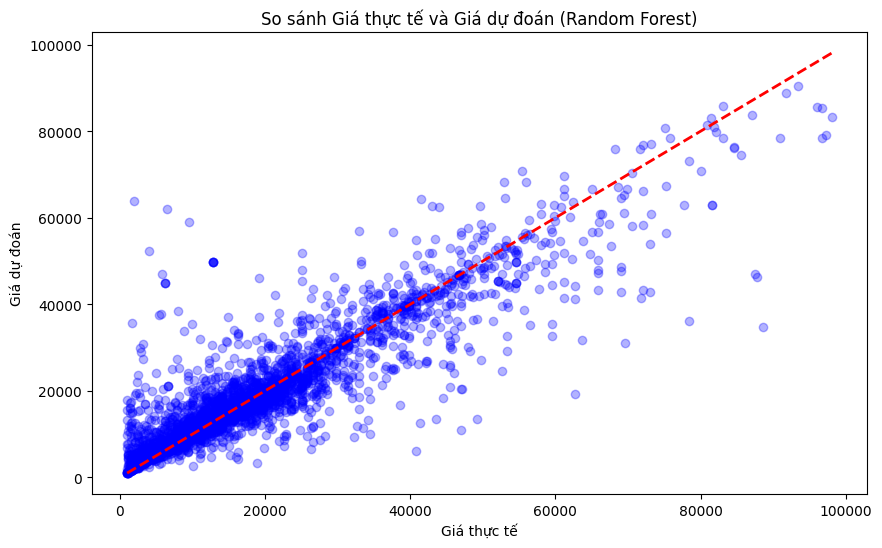

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Giá thực tế')
plt.ylabel('Giá dự đoán')
plt.title('So sánh Giá thực tế và Giá dự đoán (Random Forest)')
plt.show()


CODE THƯ VIỆN

In [17]:
import numpy as np
import pandas as pd
import pickle  
from collections import Counter
from sklearn.utils import resample

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf_node(self):
        return self.value is not None


class DecisionTree:
    # Thêm max_thresholds để giới hạn số lần duyệt cắt nhánh
    def __init__(self, min_samples_split=2, max_depth=100, n_features=None, max_thresholds=15):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.n_features = n_features
        self.max_thresholds = max_thresholds 
        self.root = None

    def fit(self, X, y):

        if not self.n_features:
            self.n_features = max(1, X.shape[1] // 3)
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_feats = X.shape

        # Kiểm tra điều kiện dừng
        if depth >= self.max_depth or n_samples < self.min_samples_split or self._variance(y) == 0:
            return Node(value=np.mean(y))
        
        # Lựa chọn ngẫu nhiên n_features 
        feat_idxs = np.random.choice(n_feats, self.n_features, replace=False)

        # Tìm cách phân chia tốt nhất
        best_feature, best_thresh = self._best_split(X, y, feat_idxs)

        # Nếu không tìm ra cách phân chia tốt
        if best_feature is None:
            return Node(value=np.mean(y))

        # Tạo nút con (đệ quy)
        left_idxs, right_idxs = self._split(X[:, best_feature], best_thresh)

        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return Node(value=np.mean(y))

        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)

        return Node(best_feature, best_thresh, left, right)

    def _best_split(self, X, y, feat_idxs):
        best_gain = -float("inf")
        split_idx, split_threshold = None, None

        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            
            # TỐI ƯU 1: Cắt giảm số lượng thresholds nếu quá nhiều 
            if len(thresholds) > self.max_thresholds:
                thresholds = np.percentile(X_column, np.linspace(5, 95, self.max_thresholds))

            for threshold in thresholds:
                gain = self._information_gain(y, X_column, threshold)

                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_threshold = threshold

        return split_idx, split_threshold

    def _information_gain(self, y, X_column, threshold):
                # Phân chia dữ liệu
        left_idxs, right_idxs = self._split(X_column, threshold)
        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return -float("inf")
        
        # Sử dụng MSE cho hồi quy
        n = len(y)
        var_parent = self._variance(y)
        var_left = self._variance(y[left_idxs])
        var_right = self._variance(y[right_idxs])

        # Tính toán IG (giảm phương sai)
        gain = var_parent - (len(left_idxs) / n * var_left + len(right_idxs) / n * var_right)
        return gain

    def _variance(self, y):
        # Tối ưu nhỏ: Tránh cảnh báo khi mảng rỗng
        return np.var(y) if len(y) > 0 else 0

    def _split(self, X_column, split_thresh):
        # TỐI ƯU 2: Dùng np.where thay cho np.argwhere.flatten() 
        left_idxs = np.where(X_column <= split_thresh)[0]
        right_idxs = np.where(X_column > split_thresh)[0]
        return left_idxs, right_idxs

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)


class RandomForest:
    def __init__(self, n_trees=100, min_samples_split=2, max_depth=100, n_features=None):
        self.n_trees = n_trees
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.n_features = n_features
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        for i in range(self.n_trees):
            X_sample, y_sample = self._bootstrap_sample(X, y)
            tree = DecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                n_features=self.n_features
            )
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)
            if (i + 1) % 10 == 0:
                print(f"  [+] Đã train {i + 1}/{self.n_trees} cây")

    def _bootstrap_sample(self, X, y):
        X_sample, y_sample = resample(X, y, replace=True)
        return X_sample, y_sample

    def predict(self, X):
        # TỐI ƯU 3: Bỏ chuyển vị .T, tính trung bình theo axis=0 
        predictions = np.array([tree.predict(X) for tree in self.trees])
        y_pred = np.mean(predictions, axis=0)
        return y_pred


if __name__ == "__main__":
    print("Đang load data...")
    train = pd.read_csv("car_price_train_clean.csv")
    feature_cols = [c for c in train.columns if c != "Price"]
    X_train = train[feature_cols].values
    y_train = train["Price"].values

    print(f"Dữ liệu huấn luyện: {X_train.shape}")

    # Khởi tạo và Train 
    rf = RandomForest(n_trees=100, max_depth=10, min_samples_split=5)
    rf.fit(X_train, y_train)

    # LƯU MÔ HÌNH ĐÃ TRAIN
    with open('random_forest_model.pkl', 'wb') as f:
        pickle.dump(rf, f)
    
    print("\n Đã Train xong và lưu mô hình thành công!")

Đang load data...
Dữ liệu huấn luyện: (12466, 15)
  [+] Đã train 10/100 cây
  [+] Đã train 20/100 cây
  [+] Đã train 30/100 cây
  [+] Đã train 40/100 cây
  [+] Đã train 50/100 cây
  [+] Đã train 60/100 cây
  [+] Đã train 70/100 cây
  [+] Đã train 80/100 cây
  [+] Đã train 90/100 cây
  [+] Đã train 100/100 cây

 Đã Train xong và lưu mô hình thành công!


ĐÁNH GIÁ CÁC CHỈ SỐ

In [18]:
import pandas as pd
import numpy as np
import pickle
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error

# Import các class cần thiết từ file rf2.py để pickle có thể giải tuần tự mô hình thành công
from rf2 import RandomForest, DecisionTree, Node

# 1. Đọc dữ liệu tập Test đã làm sạch
test_data = pd.read_csv("car_price_test_clean.csv")
feature_cols = [c for c in test_data.columns if c != "Price"]
X_test = test_data[feature_cols].values
y_test = test_data["Price"].values

# 2. Tải mô hình tự viết đã train và lưu thành công
with open('random_forest_model.pkl', 'rb') as f:
    model_custom = pickle.load(f)

# 3. Dự đoán giá xe trên tập Test
y_pred = model_custom.predict(X_test)

# 4. Tính toán các chỉ số đánh giá tương tự mô hình của sklearn
mae   = mean_absolute_error(y_test, y_pred)
mse   = mean_squared_error(y_test, y_pred)
rmse  = np.sqrt(mse)
r2    = r2_score(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)
mape  = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
n     = len(y_test)
p     = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# 5. In kết quả đánh giá chi tiết
print("📊 ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST TỰ VIẾT (CUSTOM)")
print("=" * 50)
print(f"  MAE          : {mae:,.2f} $")
print(f"  MSE          : {mse:,.2f}")
print(f"  RMSE         : {rmse:,.2f} $")
print(f"  Median AE    : {medae:,.2f} $")
print(f"  MAPE         : {mape:.2f} %")
print(f"  R2 Score     : {r2:.4f}")
print(f"  Adjusted R2  : {adj_r2:.4f}")


📊 ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST TỰ VIẾT (CUSTOM)
  MAE          : 4,998.71 $
  MSE          : 55,829,601.49
  RMSE         : 7,471.92 $
  Median AE    : 3,254.33 $
  MAPE         : 62.44 %
  R2 Score     : 0.7679
  Adjusted R2  : 0.7667


DEMO


In [19]:
import streamlit as st
import pandas as pd
import numpy as np
import pickle

# 1. BẮT BUỘC IMPORT CLASS CODE TAY TRƯỚC KHI LOAD MODEL
from rf2 import Node, DecisionTree, RandomForest

st.set_page_config(page_title="Định Giá Xe Nhóm 5", page_icon="🚗", layout="wide")

# 2. HÀM LOAD ASSETS VÀ HOTFIX PHÔNG CHỮ TỰ ĐỘNG
@st.cache_resource
def load_assets():
    # Load mô hình Random Forest code tay
    with open("best_rf_model.pkl", "rb") as f:
        model = pickle.load(f)
        
    # Load từ điển mã hóa Target Encoding
    with open("target_encoders.pkl", "rb") as f:
        encoders = pickle.load(f)
        
    # 🔥 HOTFIX TRÊN WEB: Quét qua toàn bộ từ điển, ép các key lỗi "???" hoặc "სხვა" thành "Other"
    for col in ['Manufacturer', 'Model', 'Category', 'Fuel type', 'Gear box type', 'Drive wheels', 'Color', 'Leather interior']:
        if col in encoders:
            cleaned_dict = {}
            for k, v in encoders[col].items():
                if '?' in str(k) or 'სხვა' in str(k) or str(k).strip() == "":
                    cleaned_dict['Other'] = v
                else:
                    cleaned_dict[k] = v
            encoders[col] = cleaned_dict
            
    return model, encoders

# Khởi chạy nạp tài nguyên
try:
    model, encoders = load_assets()
    global_mean = encoders.get('global_mean', 15000)
except FileNotFoundError:
    st.error("❌ Thiếu file 'random_forest_model.pkl' hoặc 'target_encoders.pkl'. Vui lòng kiểm tra lại thư mục!")
    st.stop()

# ==========================================
# GIAO DIỆN NHẬP LIỆU CHÍNH
# ==========================================
st.title("🚗 Định Giá Xe Cũ (Nhóm 5)")
st.markdown("Nhập các thông số chiếc xe của bạn, AI sẽ phân tích xu hướng thị trường và đưa ra mức giá hợp lý nhất!")
st.markdown("---")

st.header("📋 Thông số kỹ thuật")

col1, col2, col3 = st.columns(3)

with col1:
    # Hãng xe (Sắp xếp A-Z)
    mfg_list = sorted(list(encoders.get('Manufacturer', {"TOYOTA": 0}).keys()))
    manufacturer = st.selectbox("Hãng xe", mfg_list)
    
    # DÒNG XE (Tự động lọc theo Hãng xe vừa chọn)
    mapping = encoders.get('mfg_model_mapping', {})
    
    if mapping and manufacturer in mapping:
        raw_models = mapping[manufacturer]
        model_list = sorted(list(set(['Other' if '?' in str(m) or 'სხვა' in str(m) else m for m in raw_models])))
    else:
        raw_models = list(encoders.get('Model', {"Other": 0}).keys())
        model_list = sorted(list(set(['Other' if '?' in str(m) or 'სხვა' in str(m) else m for m in raw_models])))
        
    car_model = st.selectbox("Dòng xe (Model)", model_list)
    
    category_list = sorted(list(encoders.get('Category', {"Sedan": 0}).keys()))
    category = st.selectbox("Phân khúc (Category)", category_list)
    
    prod_year = st.number_input("Năm sản xuất", min_value=1990, max_value=2024, value=2015)
    
    color_list = sorted(list(encoders.get('Color', {"Black": 0}).keys()))
    color = st.selectbox("Màu sắc ngoại thất", color_list)

with col2:
    engine_volume = st.number_input("Dung tích động cơ (Liters)", min_value=0.5, max_value=8.0, value=2.0, step=0.1)
    is_turbo = st.selectbox("Động cơ có Turbo tăng áp không?", ["No", "Yes"])
    
    fuel_list = sorted(list(encoders.get('Fuel type', {"Petrol": 0}).keys()))
    fuel_type = st.selectbox("Loại nhiên liệu sử dụng", fuel_list)
    
    leather_list = sorted(list(encoders.get('Leather interior', {"Yes": 0}).keys()))
    leather = st.selectbox("Nội thất bọc da?", leather_list)
    
    cylinders = st.number_input("Số xy-lanh (Cylinders)", min_value=2, max_value=16, value=4)

with col3:
    mileage = st.number_input("Số Kilomet đã đi (Mileage)", min_value=0, value=50000, step=1000)
    
    gear_list = sorted(list(encoders.get('Gear box type', {"Automatic": 0}).keys()))
    gear_box = st.selectbox("Hộp số xe", gear_list)
    
    drive_list = sorted(list(encoders.get('Drive wheels', {"Front": 0}).keys()))
    drive_wheels = st.selectbox("Hệ thống dẫn động", drive_list)
    
    # 🔥 ĐÃ CẬP NHẬT: Thanh trượt (slider) đổi thành Hộp chọn (selectbox) từ 0 đến 16 túi khí
    airbags = st.selectbox("Số lượng túi khí an toàn", list(range(17)), index=4) 
    
    levy = st.number_input("Thuế nhập khẩu / Phí trước bạ (Levy - USD)", min_value=0, value=1000)

st.markdown("---")

# ==========================================
# XỬ LÝ LOGIC KHI BẤM NÚT ĐỰ ĐOÁN
# ==========================================
if st.button("🚀 KÍCH HOẠT AI ĐỊNH GIÁ", use_container_width=True):
    with st.spinner("Mô hình Random Forest đang xử lý dữ liệu..."):
        
        encoded_manufacturer = encoders['Manufacturer'].get(manufacturer, global_mean)
        encoded_model = encoders['Model'].get(car_model, global_mean)
        encoded_category = encoders['Category'].get(category, global_mean)
        encoded_leather = encoders['Leather interior'].get(leather, global_mean)
        encoded_fuel = encoders['Fuel type'].get(fuel_type, global_mean)
        encoded_gear = encoders['Gear box type'].get(gear_box, global_mean)
        encoded_drive = encoders['Drive wheels'].get(drive_wheels, global_mean)
        encoded_color = encoders['Color'].get(color, global_mean)
        
        # Khớp với lựa chọn "Yes"/"No" ở selectbox giao diện
        turbo_val = 1 if is_turbo == "Yes" else 0
        # Tính toán tuổi xe Car_Age
        car_age = 2024 - prod_year
        
        # Sắp xếp đúng 15 cột theo thứ tự train: Levy, Manufacturer, Model, Category, Fuel type, Engine volume, Mileage, Leather interior, Cylinders, Gear box type, Drive wheels, Color, Airbags, is_Turbo, Car_Age
        X_input = np.array([[
            levy,                   # 1. Levy
            encoded_manufacturer,   # 2. Manufacturer
            encoded_model,          # 3. Model
            encoded_category,       # 4. Category
            encoded_fuel,           # 5. Fuel type
            engine_volume,          # 6. Engine volume
            mileage,                # 7. Mileage
            encoded_leather,        # 8. Leather interior
            cylinders,              # 9. Cylinders
            encoded_gear,           # 10. Gear box type
            encoded_drive,          # 11. Drive wheels
            encoded_color,          # 12. Color
            airbags,                # 13. Airbags
            turbo_val,              # 14. is_Turbo
            car_age                 # 15. Car_Age
        ]])
        
        try:
            pred_price = model.predict(X_input)[0]
            st.success("🎉 PHÂN TÍCH THỊ TRƯỜNG HOÀN TẤT!")
            st.markdown(f"<h1 style='text-align: center; color: #ff4b4b;'>${pred_price:,.0f}</h1>", unsafe_allow_html=True)
            st.info("💡 Kết quả được tính toán dựa trên thuật toán Random Forest, phản ánh mức độ khấu hao thực tế.")
        except Exception as e:
            st.error(f"❌ Lỗi xử lý cấu trúc mô hình: {e}")

2026-05-19 23:14:22.556 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-19 23:14:22.562 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-19 23:14:22.795 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-19 23:14:23.054 
  command:

    streamlit run C:\Users\Khanh Huyen\AppData\Roaming\Python\Python314\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-19 23:14:23.055 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-19 23:14:23.056 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-19 23:14:2

In [20]:
!streamlit run app.py


^C
